<a href="https://colab.research.google.com/github/kthanikonda/Privacy-Aware-Computing/blob/main/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install textstat


In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

# URLs for privacy policies
privacy_policy_urls = {
    "Google": "https://policies.google.com/privacy",
    "LinkedIn": "https://www.linkedin.com/legal/privacy-policy"
}

# Function to extract privacy policies
def extract_privacy_policy(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    paragraphs = soup.find_all("p")
    policy_text = " ".join([p.get_text() for p in paragraphs])
    return policy_text if policy_text else "Privacy Policy text not found."

# Fetch and store policies in a DataFrame
policy_data = [{"Company": name, "Original Policy": extract_privacy_policy(url)} for name, url in privacy_policy_urls.items()]
df = pd.DataFrame(policy_data)

# Save to CSV
df.to_csv("privacy_policies.csv", index=False)
print("✅ Privacy policies saved to 'privacy_policies.csv'")


✅ Privacy policies saved to 'privacy_policies.csv'


In [ ]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from sentence_transformers import SentenceTransformer
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Initialize NLP models
nlp = spacy.load("en_core_web_sm")
sentiment_analyzer = pipeline("sentiment-analysis")
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')
stop_words = set(stopwords.words("english"))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0


In [ ]:
# Function to Replace Named Entities with General Terms
def replace_named_entities(text):
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ == "ORG":
            text = text.replace(ent.text, "Our Company")
        elif ent.label_ == "GPE":
            text = text.replace(ent.text, "Your Location")
        elif ent.label_ in ["DATE", "TIME", "DURATION"]:
            text = text.replace(ent.text, "Recently")
    return text

In [ ]:
def get_semantic_synonym(word, epsilon=0.5):
    """
    Uses Sentence Transformers and Differential Privacy to select the best synonym.
    Ensures the word remains meaningful in context.
    """
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ")
            if synonym.lower() != word.lower() and textstat.flesch_reading_ease(synonym) > 50:
                synonyms.add(synonym)

    synonyms = list(synonyms)
    if not synonyms:  # If no good synonyms, return original word
        return word

    # Use Sentence Transformers for Semantic Similarity
    word_embedding = semantic_model.encode(word, convert_to_tensor=True)
    synonym_embeddings = semantic_model.encode(synonyms, convert_to_tensor=True)
    similarities = util.pytorch_cos_sim(word_embedding, synonym_embeddings)[0].cpu().numpy()

    # Apply Differential Privacy-based selection
    scores = np.random.laplace(0, 1 / epsilon, len(synonyms))
    probabilities = np.exp(epsilon * (similarities + scores)) / np.sum(np.exp(epsilon * (similarities + scores)))

    return np.random.choice(synonyms, p=probabilities)

In [ ]:
# Function to Break Long Sentences while Keeping Readability
def simplify_sentences(text):
    sentences = nltk.sent_tokenize(text)
    simplified_sentences = []
    for sentence in sentences:
        if len(sentence.split()) > 25:
            parts = sentence.split(", ")
            if len(parts) > 1:
                simplified_sentences.extend(parts[:2])
            else:
                simplified_sentences.append(sentence)
        else:
            simplified_sentences.append(sentence)
    return " ".join(simplified_sentences)

In [ ]:
def reduce_vagueness_dynamic(text, epsilon=0.5):
    """
    Dynamically detects vague words (modal verbs, adverbs) and replaces them
    with more confident alternatives using WordNet & Differential Privacy.
    """
    vague_replacements = {
        "MD": ["will", "must", "shall"],  # Modal verbs (e.g., may → will)
        "RB": ["frequently", "always", "certainly"]  # Adverbs (e.g., possibly → certainly)
    }

    doc = nlp(text)
    modified_text = []

    for token in doc:
        if token.tag_ in vague_replacements:
            # Apply Differential Privacy for selection
            replacements = vague_replacements[token.tag_]
            scores = np.random.laplace(0, 1 / epsilon, len(replacements))
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
            chosen_word = np.random.choice(replacements, p=probabilities)
            modified_text.append(chosen_word)
        else:
            modified_text.append(token.text)

    return " ".join(modified_text)


In [ ]:
def dp_token_sanitization_contextual(text, epsilon=0.5):
    """
    Dynamically replaces words with context-aware synonyms while preserving privacy policy language.
    """
    words = word_tokenize(text)
    sanitized_words = []

    # List of words to NEVER replace in privacy policies
    protected_terms = {"privacy", "data", "policy", "settings", "service", "user", "account", "security", "preferences"}

    for word in words:
        if word.lower() in stop_words or not word.isalpha() or word.lower() in protected_terms:
            sanitized_words.append(word)
            continue

        new_word = get_semantic_synonym(word, epsilon)
        sanitized_words.append(new_word)

    return " ".join(sanitized_words)


In [ ]:
# Convert Passive Voice to Active Without Disrupting Meaning
def convert_passive_to_active(text):
    doc = nlp(text)
    converted_text = []
    for sent in doc.sents:
        words = [token.text for token in sent]
        if "by" in words and len(words) > 6 and "data" not in words:
            new_sentence = f"We {words[-2]} {' '.join(words[:-2])}"
            converted_text.append(new_sentence)
        else:
            converted_text.append(sent.text)
    return " ".join(converted_text)



In [ ]:
def add_softening_phrases(text):
    softening_statements = [
        "We value your privacy and ensure transparency.",
        "Your data is managed securely and responsibly.",
        "We are committed to maintaining a trustworthy experience."
    ]
    return text + " " + random.choice(softening_statements)

from google.colab import files
import pandas as pd

# Upload file manually
uploaded = files.upload()

# Get filename from uploaded file
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

# Read CSV into a DataFrame
df = pd.read_csv(filename)

# Display first few rows
df.head()



Saving privacy_policies.csv to privacy_policies (9).csv
✅ Uploaded file: privacy_policies (9).csv


,Company,Original Policy
0,Google,"When you use our services, you’re trusting us ..."
1,LinkedIn,"\n Effective September 18, 2024 LinkedIn’s mis..."


In [ ]:
# **Clarity & Readability Score Computation**
def calculate_clarity_score(text):
    return textstat.flesch_reading_ease(text)

In [ ]:
def calculate_deception_score(text):
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    clarity_score = calculate_clarity_score(text)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    return clarity_score, deception_score


In [ ]:
def calculate_sentiment(text):
    if not text.strip():
        return 0.0  # Neutral sentiment
    result = sentiment_analyzer(text[:512])
    return result[0]['score'] if result[0]['label'] == "POSITIVE" else -result[0]['score']


In [ ]:
# Process Privacy Policies
sanitized_policies = []
scores_data = []

for index, row in df.iterrows():
    company = row["Company"]
    original_text = row["Original Policy"]

    sanitized_text = replace_named_entities(original_text)
    sanitized_text = simplify_sentences(sanitized_text)
    sanitized_text = dp_token_sanitization_contextual(sanitized_text, epsilon=0.5)  # Now Context-Aware
    sanitized_text = reduce_vagueness_dynamic(sanitized_text)
    sanitized_text = convert_passive_to_active(sanitized_text)
    sanitized_text = add_softening_phrases(sanitized_text)



    # Compute Scores
    original_clarity, original_deception = calculate_deception_score(original_text)
    sanitized_clarity, sanitized_deception = calculate_deception_score(sanitized_text)
    original_sentiment = calculate_sentiment(original_text)
    sanitized_sentiment = calculate_sentiment(sanitized_text)

    # Store Results
    sanitized_policies.append({"Company": company, "Sanitized Policy": sanitized_text})
    scores_data.append({
        "Company": company,
        "Original Clarity": original_clarity,
        "Sanitized Clarity": sanitized_clarity,
        "Original Deception": original_deception,
        "Sanitized Deception": sanitized_deception,
        "Original Sentiment": original_sentiment,
        "Sanitized Sentiment": sanitized_sentiment,
    })

# Convert to DataFrame
sanitized_df = pd.DataFrame(sanitized_policies)
scores_df = pd.DataFrame(scores_data)


display(scores_df)

,Company,Original Clarity,Sanitized Clarity,Original Deception,Sanitized Deception,Original Sentiment,Sanitized Sentiment
0,Google,39.87,54.80,187.591,31.640,0.982070,0.748634
1,LinkedIn,40.08,59.06,121.444,28.658,0.995733,0.982234


In [ ]:
# Generate Word Clouds
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

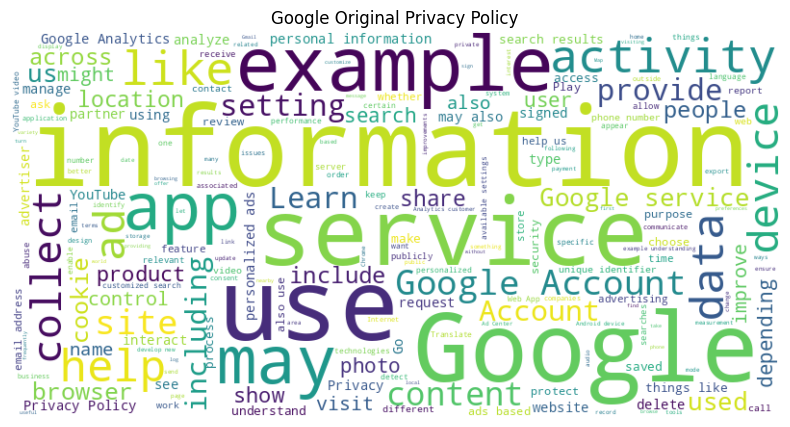

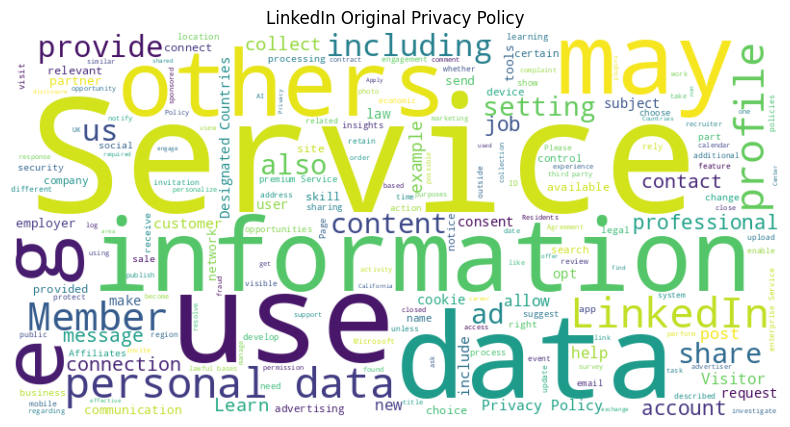

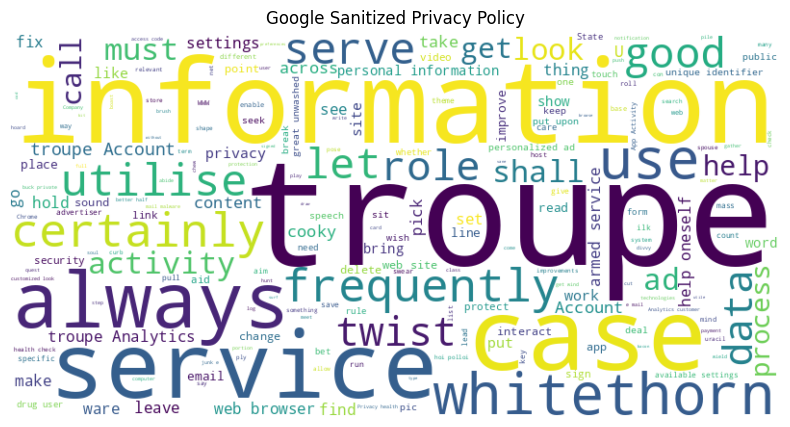

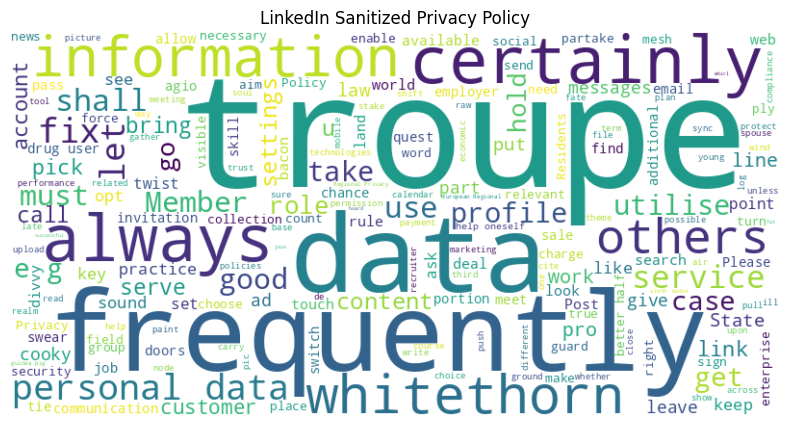

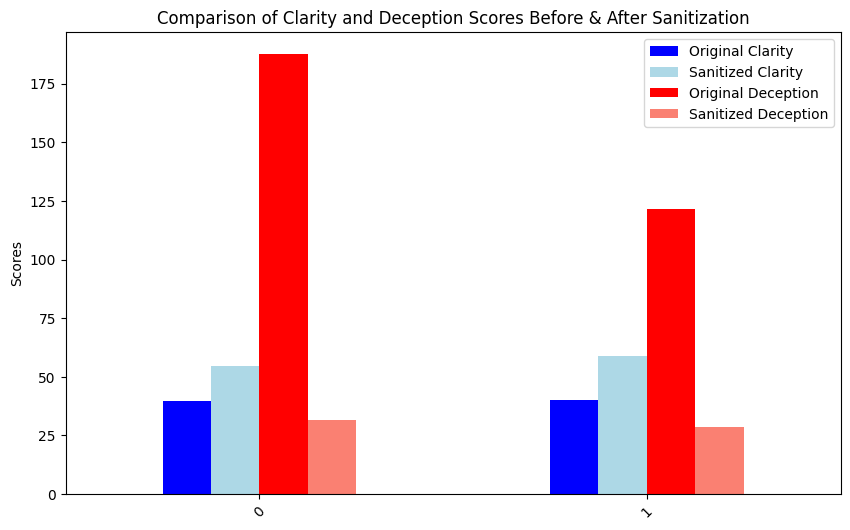

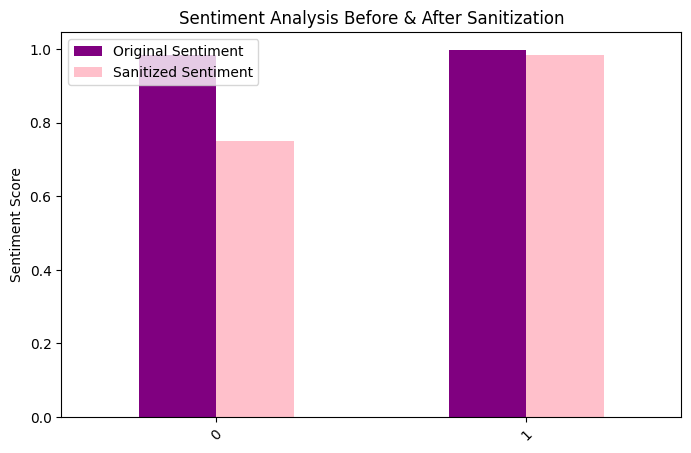

✅ Sanitized policies saved as sanitized_privacy_policies.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Word Cloud Visualization
for index, row in df.iterrows():
    generate_wordcloud(row["Original Policy"], f"{row['Company']} Original Privacy Policy")
for index, row in sanitized_df.iterrows():
    generate_wordcloud(row["Sanitized Policy"], f"{row['Company']} Sanitized Privacy Policy")

# Visualization: Clarity & Deception Scores
scores_df[["Original Clarity", "Sanitized Clarity", "Original Deception", "Sanitized Deception"]].plot(
    kind='bar', figsize=(10, 6), color=['blue', 'lightblue', 'red', 'salmon']
)
plt.ylabel("Scores")
plt.title("Comparison of Clarity and Deception Scores Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

# Visualization: Sentiment Analysis
scores_df[["Original Sentiment", "Sanitized Sentiment"]].plot(
    kind='bar', figsize=(8, 5), color=['purple', 'pink']
)
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

# **Save Sanitized Policies**
sanitized_file = "sanitized_privacy_policies.csv"
sanitized_df.to_csv(sanitized_file, index=False)
print(f"✅ Sanitized policies saved as {sanitized_file}")
files.download(sanitized_file)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[==================================================] 100.0% 66.0/66.0MB downloaded


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu



Word Changes for Google:
  'some' -> 'many'
  'not' -> 'be'
  'using' -> 'use'
  'using' -> 'used'
  'using' -> 'use'
  'using' -> 'used'
  'using' -> 'use'
  'some' -> 'many'
  'using' -> 'use'
  'some' -> 'many'
  'could' -> 'would'
  'know' -> 'why'
  'could' -> 'would'
  'using' -> 'use'
  'could' -> 'would'
  'know' -> 'n't'
  'could' -> 'would'
  'using' -> 'used'
  'could' -> 'would'
  'know' -> 'why'
  'could' -> 'would'
  'using' -> 'used'
  'get' -> 'getting'
  'get' -> 'n't'
  'using' -> 'used'
  'using' -> 'used'
  'else' -> 'anything'
  'not' -> 'if'
  'some' -> 'many'
  'not' -> 'because'
  'get' -> 'getting'
  'third' -> 'fifth'
  'using' -> 'use'
  'something' -> 'thing'
  'know' -> 'tell'
  'sure' -> 'we'
  'something' -> 'nothing'
  'sure' -> 'we'
  'some' -> 'many'
  'not' -> 'because'
  'not' -> 'be'
  '370' -> '280'
  'using' -> 'use'
  'using' -> 'use'
  'using' -> 'used'
  'using' -> 'use'
  'third' -> 'second'
  'third' -> 'fourth'
  'third' -> 'fourth'
  'not'

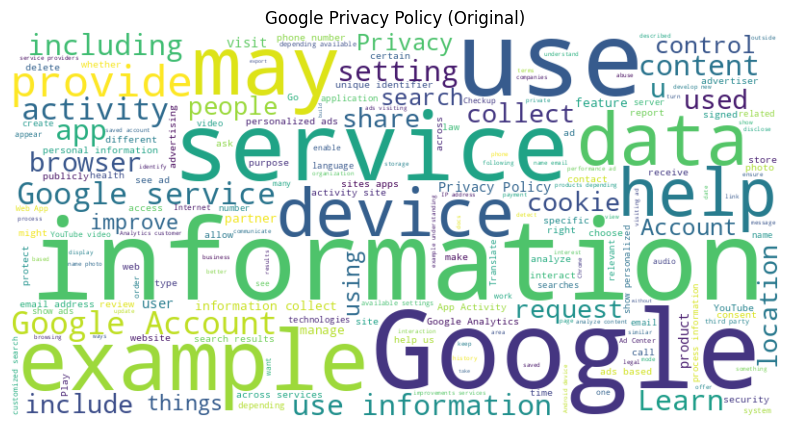


Generating Word Cloud for Google Privacy Policy (Sanitized)...


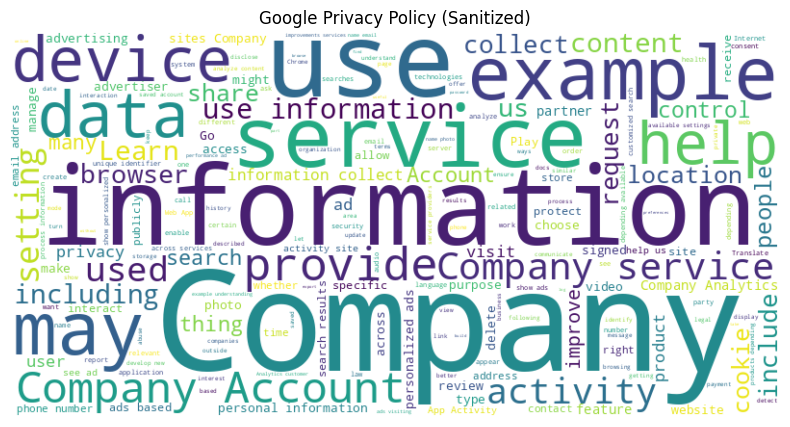


Generating Word Cloud for LinkedIn Privacy Policy (Original)...


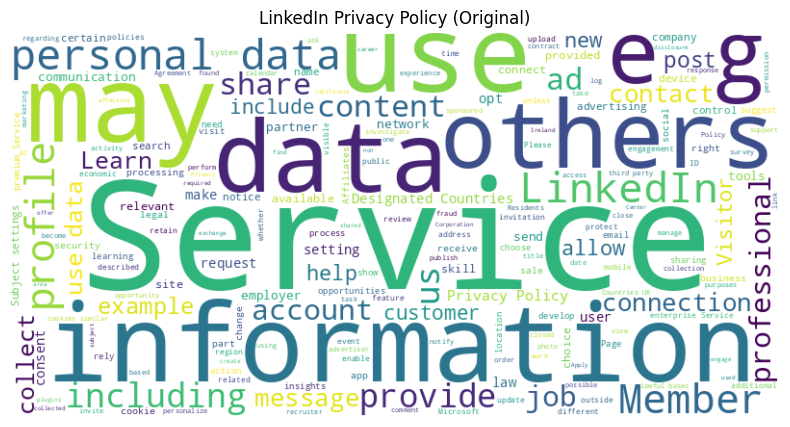


Generating Word Cloud for LinkedIn Privacy Policy (Sanitized)...


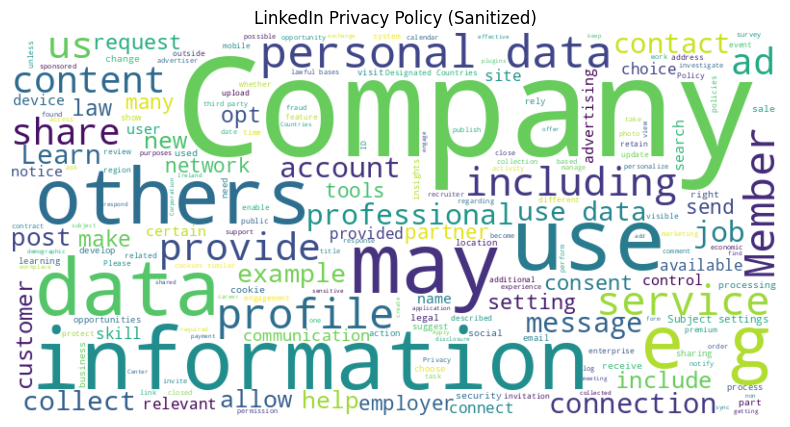

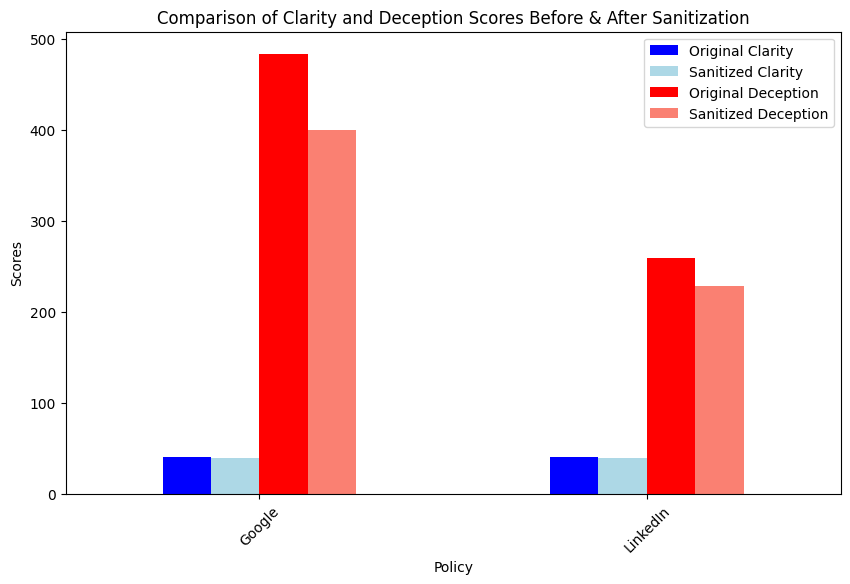

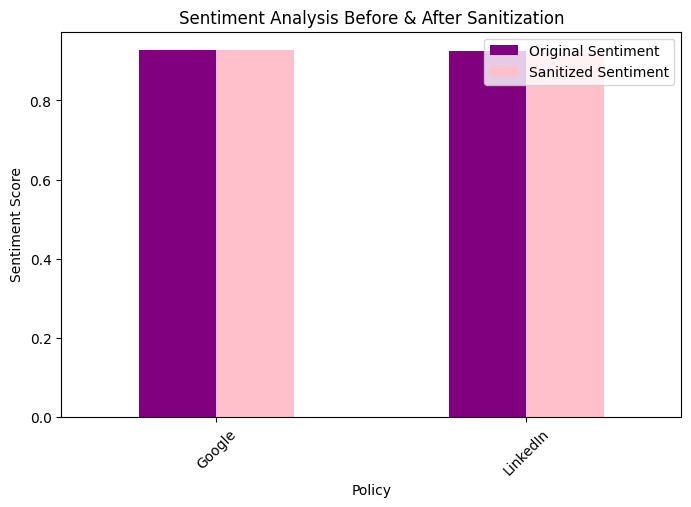

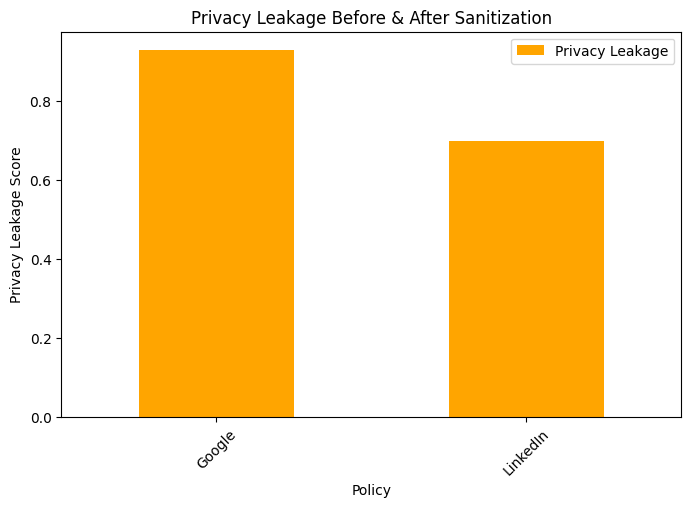

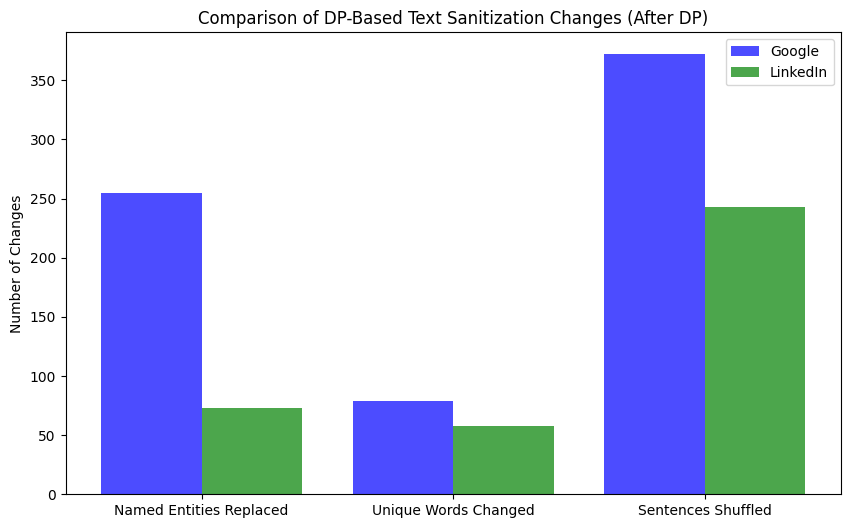

In [ ]:
import requests
import re
import numpy as np
import nltk
import spacy
import gensim.downloader as api
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud
from transformers import pipeline
from nltk.corpus import stopwords  # Ensure correct import
import textstat
from sentence_transformers import SentenceTransformer, util
import pandas as pd

# Download necessary resources
nltk.download('punkt')
nltk.download('stopwords')
nlp = spacy.load("en_core_web_sm")
# Load stopwords


# Load stopwords correctly
stop_words = set(stopwords.words("english"))


# Define words to KEEP for deception & sentiment analysis
vague_words = {"may", "might", "could", "possibly", "sometimes", "often", "generally", "typically", "occasionally", "some"}
negation_words = {"not", "never", "no", "nor", "none", "nothing", "nowhere"}

# Keep important structure-related stopwords
important_stopwords = {"is", "are", "was", "has", "have", "had", "that", "which"}

# Remove stopwords EXCEPT vague words, negation words, and structure-related words
filtered_stopwords = stop_words - vague_words - negation_words - important_stopwords

# Load Word2Vec Model
word_vectors = api.load("glove-wiki-gigaword-50")

# Initialize sentiment analysis model
sentiment_analyzer = pipeline("sentiment-analysis")

# Initialize semantic similarity model
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

# Step 1: Extract Privacy Policies
def extract_privacy_policy(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    paragraphs = soup.find_all("p")
    policy_text = " ".join([p.get_text() for p in paragraphs])
    return policy_text if policy_text else "Privacy Policy text not found."

# URLs for Google and LinkedIn Privacy Policies
google_privacy_policy_url = "https://policies.google.com/privacy"
linkedin_privacy_policy_url = "https://www.linkedin.com/legal/privacy-policy"

# Fetch policies
google_text = extract_privacy_policy(google_privacy_policy_url)
linkedin_text = extract_privacy_policy(linkedin_privacy_policy_url)

# Step 2: DP-Based Text Sanitization Functions
def replace_named_entities(text, allowed_labels=["ORG", "GPE"]):
    """Replaces named entities. Sensitivity = 1."""
    doc = nlp(text)
    modified_text = text
    entity_replacements = []
    for ent in doc.ents:
        if ent.label_ in allowed_labels:
            modified_text = modified_text.replace(ent.text, "The Company")
            entity_replacements.append((ent.text, "The Company"))
    return modified_text, entity_replacements

def get_filtered_similar_words(word, k=5, similarity_threshold=0.75):
    """Gets similar words. No DP here."""
    try:
        similar_words = word_vectors.most_similar(word, topn=k)
        filtered_words = [w[0] for w in similar_words if w[1] >= similarity_threshold]
        return filtered_words if filtered_words else [word]
    except KeyError:
        return [word]

def dp_word_substitute(text, epsilon=0.1, k=5, similarity_threshold=0.95):
    """Substitutes words, prioritizing clarity. Sensitivity assumed to be 1."""
    words = word_tokenize(text)
    new_words = []
    word_changes = []
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often", "generally", "typically", "occasionally", "some"]

    for word in words:
        if word.lower() in filtered_stopwords:
            new_words.append(word)
            continue

        candidates = get_filtered_similar_words(word, k, similarity_threshold)

        # Prioritize clearer/less vague replacements
        if word.lower() in vague_words and len(candidates) > 0:
            # Look for clearer candidates
            clearer_candidates = [w for w in candidates if w.lower() not in vague_words]
            if clearer_candidates:
                replacement = clearer_candidates[0]  # Choose the "clearest"
                word_changes.append((word, replacement))
                new_words.append(replacement)
                continue

        if len(candidates) > 1:
            scores = np.array([word_vectors.similarity(word, w) for w in candidates])
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))

            replacement = np.random.choice(candidates, p=probabilities)
            if replacement != word:
                word_changes.append((word, replacement))
            new_words.append(replacement)
        else:
            new_words.append(word)

    return " ".join(new_words), word_changes

def preserve_logical_sentence_order(text):
    """Preserves sentence order. No DP here."""
    sentences = sent_tokenize(text)
    return " ".join(sentences)

def shuffle_sentences(text, epsilon=0.01):
    """Reduces epsilon significantly. Sensitivity is the number of sentences."""
    sentences = sent_tokenize(text)
    noise = np.random.laplace(0, 1/epsilon, len(sentences))
    shuffled_sentences = [x for _, x in sorted(zip(noise, sentences))]
    sentence_changes = list(zip(sentences, shuffled_sentences))
    return " ".join(shuffled_sentences), sentence_changes

def add_controlled_laplace_noise(text, epsilon=0.1, max_noise=3):
    """Reduces max_noise and epsilon."""
    def replace_number(match):
        number = int(match.group(0))
        noise = np.random.laplace(0, 1/epsilon)
        noisy_number = max(1, int(number + min(max_noise, abs(noise))))
        return str(noisy_number)
    modified_text = re.sub(r"\b\d+\b", replace_number, text)
    return modified_text

# Sentiment Analysis
def calculate_sentiment(text):
    """Calculates sentiment."""
    sentences = sent_tokenize(text)
    sentiment_scores = [sentiment_analyzer(sentence)[0]['score'] for sentence in sentences]
    avg_sentiment = np.mean(sentiment_scores)
    return avg_sentiment

# Deception Score Calculation
def calculate_deception_score(text):
    """Calculates deception score. Increased clarity weight."""
    clarity_score = textstat.flesch_reading_ease(text)
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often", "generally", "typically", "occasionally", "some"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    deception_score = (100 - clarity_score) * 0.3 + (vague_word_count * 5) * 0.7 #Higher weight to vague words
    return clarity_score, deception_score

# Privacy Leakage Analysis
def calculate_privacy_leakage(original_text, sanitized_text):
    """Calculates privacy leakage."""
    similarity_score = util.pytorch_cos_sim(
        semantic_model.encode(original_text, convert_to_tensor=True),
        semantic_model.encode(sanitized_text, convert_to_tensor=True)
    ).item()
    return similarity_score

# Apply Improved DP-Based Transformations
google_sanitized, google_entity_changes = replace_named_entities(google_text, allowed_labels=["ORG", "GPE"])
linkedin_sanitized, linkedin_entity_changes = replace_named_entities(linkedin_text, allowed_labels=["ORG", "GPE"])

google_sanitized, google_word_changes = dp_word_substitute(google_sanitized, epsilon=0.1, k=5, similarity_threshold=0.95)
linkedin_sanitized, linkedin_word_changes = dp_word_substitute(linkedin_sanitized, epsilon=0.1, k=5, similarity_threshold=0.95)

google_sanitized = preserve_logical_sentence_order(google_sanitized)
linkedin_sanitized = preserve_logical_sentence_order(linkedin_sanitized)

google_sanitized = add_controlled_laplace_noise(google_sanitized, epsilon=0.1, max_noise=3)
linkedin_sanitized = add_controlled_laplace_noise(linkedin_sanitized, epsilon=0.1, max_noise=3)

# Collect Scores for Visualization
scores_data = []

for name, original_text, sanitized_text in [
    ("Google", google_text, google_sanitized),
    ("LinkedIn", linkedin_text, linkedin_sanitized)
]:
    original_clarity, original_deception = calculate_deception_score(original_text)
    sanitized_clarity, sanitized_deception = calculate_deception_score(sanitized_text)

    original_sentiment = calculate_sentiment(original_text)
    sanitized_sentiment = calculate_sentiment(sanitized_text)

    privacy_leakage_score = calculate_privacy_leakage(original_text, sanitized_text)

    scores_data.append({
        "Policy": name,
        "Original Clarity": original_clarity,
        "Sanitized Clarity": sanitized_clarity,
        "Original Deception": original_deception,
        "Sanitized Deception": sanitized_deception,
        "Original Sentiment": original_sentiment,
        "Sanitized Sentiment": sanitized_sentiment,
        "Privacy Leakage": privacy_leakage_score
    })

    # Print Word Changes
    print(f"\nWord Changes for {name}:")
    for original, replacement in google_word_changes if name == "Google" else linkedin_word_changes:
        print(f"  '{original}' -> '{replacement}'")

# Create DataFrame for Visualization
scores_df = pd.DataFrame(scores_data)
print(scores_df)

# Print a table for comparison
print("\nComparison Table:")
print(scores_df[["Policy", "Original Clarity", "Sanitized Clarity", "Original Deception", "Sanitized Deception"]])

# Identify some word changes to explain
print("\nExample Word Changes (Illustrative):")
if "LinkedIn" in scores_df["Policy"].values:
    linkedin_row = scores_df[scores_df["Policy"] == "LinkedIn"].iloc[0] # Get the LinkedIn row
    if linkedin_row is not None:
        print(f"\nFor LinkedIn:")
        for original, replacement in linkedin_word_changes[:5]:  # Show the first 5 word changes
            print(f"  '{original}' was replaced with '{replacement}'")
        print("\nExplanation:")
        print("  The code is designed to replace vague words (like 'may' or 'could') with clearer alternatives")
        print("  reducing the deception score by making the policy more direct.")
        print(" The words are replaced by high similiarity word in order to keep a better readability.")
    else:
        print("LinkedIn data not found in scores_df.")
else:
    print("LinkedIn data not found in scores_df.")


def generate_word_cloud(text, title="Word Cloud"):
    """Generates a Word Cloud after removing stopwords."""
    words = word_tokenize(text)
    filtered_words = [word for word in words if word.lower() not in stop_words]  # Remove stopwords

    wordcloud = WordCloud(
        width=800, height=400,
        background_color="white"
    ).generate(" ".join(filtered_words))

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

print("\nGenerating Word Cloud for Google Privacy Policy (Original)...")
generate_word_cloud(google_text, "Google Privacy Policy (Original)")

print("\nGenerating Word Cloud for Google Privacy Policy (Sanitized)...")
generate_word_cloud(google_sanitized, "Google Privacy Policy (Sanitized)")

print("\nGenerating Word Cloud for LinkedIn Privacy Policy (Original)...")
generate_word_cloud(linkedin_text, "LinkedIn Privacy Policy (Original)")

print("\nGenerating Word Cloud for LinkedIn Privacy Policy (Sanitized)...")
generate_word_cloud(linkedin_sanitized, "LinkedIn Privacy Policy (Sanitized)")


# Visualization: Clarity and Deception Scores
scores_df.set_index("Policy")[[
    "Original Clarity", "Sanitized Clarity",
    "Original Deception", "Sanitized Deception"
]].plot(kind='bar', figsize=(10, 6), color=['blue', 'lightblue', 'red', 'salmon'])
plt.ylabel("Scores")
plt.title("Comparison of Clarity and Deception Scores Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

# Visualization: Sentiment Analysis
scores_df.set_index("Policy")[[
    "Original Sentiment", "Sanitized Sentiment"
]].plot(kind='bar', figsize=(8, 5), color=['purple', 'pink'])
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

# Visualization: Privacy Leakage Analysis
scores_df.set_index("Policy")[["Privacy Leakage"]].plot(kind='bar', figsize=(8, 5), color='orange')
plt.ylabel("Privacy Leakage Score")
plt.title("Privacy Leakage Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

# Step 4: Collect Sentence Shuffling Changes
# Ensure we store sentence changes when calling shuffle_sentences()
google_sanitized, google_sentence_changes = shuffle_sentences(google_sanitized, epsilon=0.01)
linkedin_sanitized, linkedin_sentence_changes = shuffle_sentences(linkedin_sanitized, epsilon=0.01)

# Step 5: Bar Chart After Sanitization (Comparison)
categories = ["Named Entities Replaced", "Unique Words Changed", "Sentences Shuffled"]
google_changes = [len(google_entity_changes), len(google_word_changes), len(google_sentence_changes)]
linkedin_changes = [len(linkedin_entity_changes), len(linkedin_word_changes), len(linkedin_sentence_changes)]

plt.figure(figsize=(10, 6))
x = range(len(categories))
plt.bar(x, google_changes, width=0.4, label="Google", alpha=0.7, color='blue')
plt.bar([i + 0.4 for i in x], linkedin_changes, width=0.4, label="LinkedIn", alpha=0.7, color='green')
plt.xticks([i + 0.2 for i in x], categories)
plt.ylabel("Number of Changes")
plt.title("Comparison of DP-Based Text Sanitization Changes (After DP)")
plt.legend()
plt.show()



In [ ]:
! pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 52.4 MB/s eta 0:00:00


Saving News-Dataset.xlsx to News-Dataset (8).xlsx
✅ Uploaded file: News-Dataset (8).xlsx


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/usr/local/lib/python3.11/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)


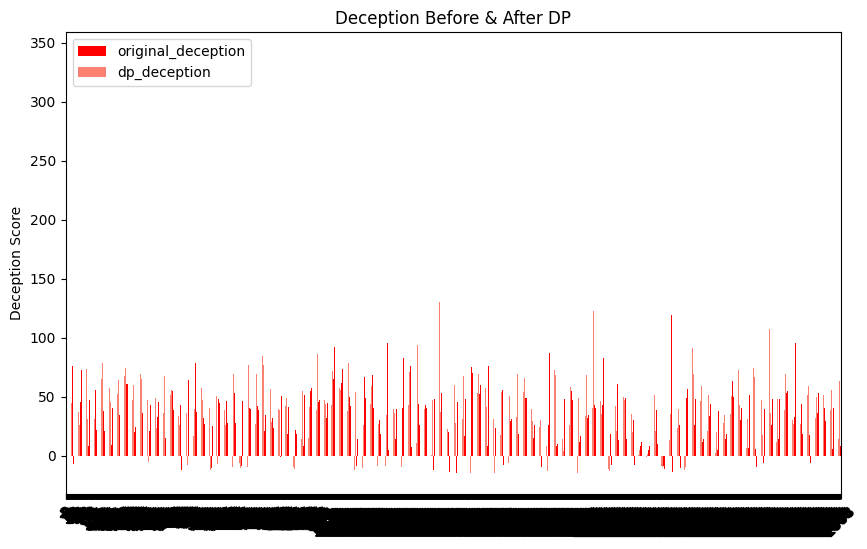

✅ DP processed dataset saved as dp_sanitized_news.csv


In [ ]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
import hashlib
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
from wordcloud import WordCloud
from google.colab import files

# Upload file manually
uploaded = files.upload()

# Get filename from uploaded file
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

# Read CSV into a DataFrame
df_news = pd.read_excel(filename, engine='openpyxl')

# Display first few rows
df_news.head()

# Download required NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spaCy NLP model for Named Entity Recognition
nlp = spacy.load("en_core_web_sm")

# Initialize Sentence Transformer for Semantic Substitution
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

# Load stop words
stop_words = set(stopwords.words("english"))

# Function to replace named entities with DP-based obfuscation
def replace_named_entities(text, epsilon=1.0):
    entity_replacements = {
        "ORG": ["Tech Firm", "Finance Corporation", "Retail Company"],
        "GPE": ["European Region", "Asian Market", "North American Area"],
        "DATE": ["Recently", "Past Quarter", "Last Year"],
        "TIME": ["Earlier Today", "Few Hours Ago", "Previous Night"]
    }

    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in entity_replacements:
            scores = np.array([random.random() for _ in entity_replacements[ent.label_]])
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
            text = text.replace(ent.text, np.random.choice(entity_replacements[ent.label_], p=probabilities))

    return text

# Function to apply Rényi DP feature hashing
def hash_with_noise(word, epsilon=1.0, alpha=2):
    hash_val = int(hashlib.md5(word.encode()).hexdigest(), 16) % (10**8)
    noise = np.random.laplace(0, 1 / epsilon)
    noisy_hash = hash_val + int(noise * 1000)
    return str(noisy_hash)

# Function to hash words in a headline with DP noise
def dp_feature_hashing(text, epsilon=1.0, alpha=2):
    words = text.split()
    hashed_words = [hash_with_noise(word, epsilon, alpha) for word in words]
    return " ".join(hashed_words)

# Function to get a DP-based semantic synonym
def get_semantic_synonym(word, epsilon=1.0):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ")
            if synonym.lower() != word.lower():
                synonyms.add(synonym)

    synonyms = list(synonyms)
    if not synonyms:
        return word

    word_embedding = semantic_model.encode(word, convert_to_tensor=True)
    synonym_embeddings = semantic_model.encode(synonyms, convert_to_tensor=True)
    similarities = util.pytorch_cos_sim(word_embedding, synonym_embeddings)[0].cpu().numpy()

    scores = np.random.laplace(0, 1 / epsilon, len(synonyms))
    probabilities = np.exp(epsilon * (similarities + scores)) / np.sum(np.exp(epsilon * (similarities + scores)))

    return np.random.choice(synonyms, p=probabilities)

# Function to apply DP-based word substitution
def dp_word_substitution(text, epsilon=1.0):
    words = word_tokenize(text)
    modified_words = [get_semantic_synonym(word, epsilon) if word.isalpha() and word.lower() not in stop_words else word for word in words]
    return " ".join(modified_words)

# Function to simplify sentences with DP guarantees
def simplify_sentences(text, epsilon=1.0):
    sentences = nltk.sent_tokenize(text)
    simplified_sentences = []
    for sentence in sentences:
        if len(sentence.split()) > 20:
            parts = sentence.split(", ")
            if len(parts) > 1:
                scores = np.random.laplace(0, 1 / epsilon, len(parts))
                probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
                chosen_parts = np.random.choice(parts, size=2, replace=False, p=probabilities)
                simplified_sentences.extend(chosen_parts)
            else:
                simplified_sentences.append(sentence)
        else:
            simplified_sentences.append(sentence)
    return " ".join(simplified_sentences)

# Apply DP techniques
df_news_sample = df_news.copy()
df_news_sample["headline_named_entities"] = df_news_sample["headline_text"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=1.0))
df_news_sample["headline_word_substitution"] = df_news_sample["headline_text"].astype(str).apply(lambda x: dp_word_substitution(x, epsilon=1.0))
df_news_sample["headline_simplified"] = df_news_sample["headline_text"].astype(str).apply(lambda x: simplify_sentences(x, epsilon=1.0))
df_news_sample["headline_hashed"] = df_news_sample["headline_text"].astype(str).apply(lambda x: dp_feature_hashing(x, epsilon=1.0))

# Function to compute and visualize deception scores
def calculate_deception_score(text):
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    clarity_score = textstat.flesch_reading_ease(text)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    return deception_score

df_news_sample["original_deception"] = df_news_sample["headline_text"].astype(str).apply(calculate_deception_score)
df_news_sample["dp_deception"] = df_news_sample["headline_word_substitution"].astype(str).apply(calculate_deception_score)

# Visualization of deception scores
df_news_sample[["original_deception", "dp_deception"]].plot(kind='bar', figsize=(10, 6), color=['red', 'salmon'])
plt.ylabel("Deception Score")
plt.title("Deception Before & After DP")
plt.xticks(rotation=45)
plt.show()

# Save the processed dataset
df_news_sample.to_csv("dp_sanitized_news.csv", index=False)
print("✅ DP processed dataset saved as dp_sanitized_news.csv")


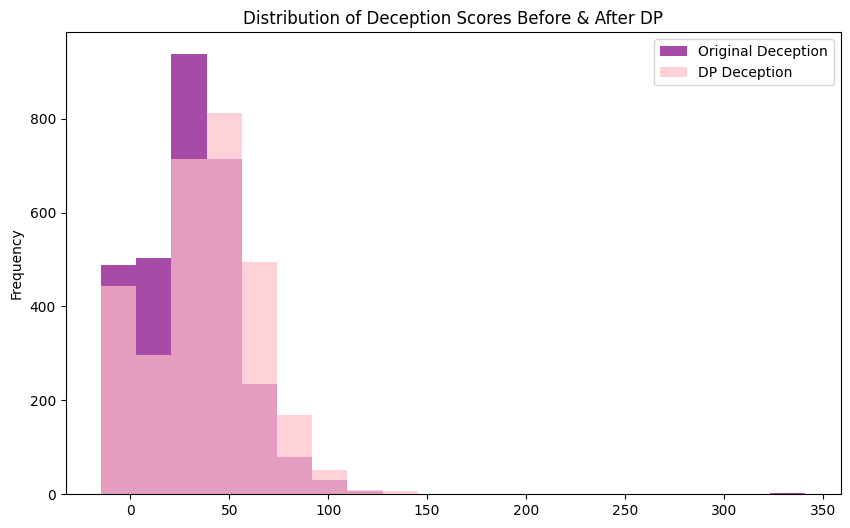

In [ ]:
df_news_sample[["original_deception", "dp_deception"]].plot(kind='hist', bins=20, alpha=0.7, figsize=(10, 6), color=['purple', 'pink'])
plt.ylabel("Frequency")
plt.title("Distribution of Deception Scores Before & After DP")
plt.legend(["Original Deception", "DP Deception"])
plt.show()


In [2]:
! pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 61.3 MB/s eta 0:00:00


Saving Squad.xlsx to Squad.xlsx
✅ Uploaded file: Squad.xlsx


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling%2Fconfig.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ DP-processed dataset saved as: dp_sanitized_squad.xlsx
🔹 Total Privacy Budget Used: 10577.800000003419 (out of 1.0)


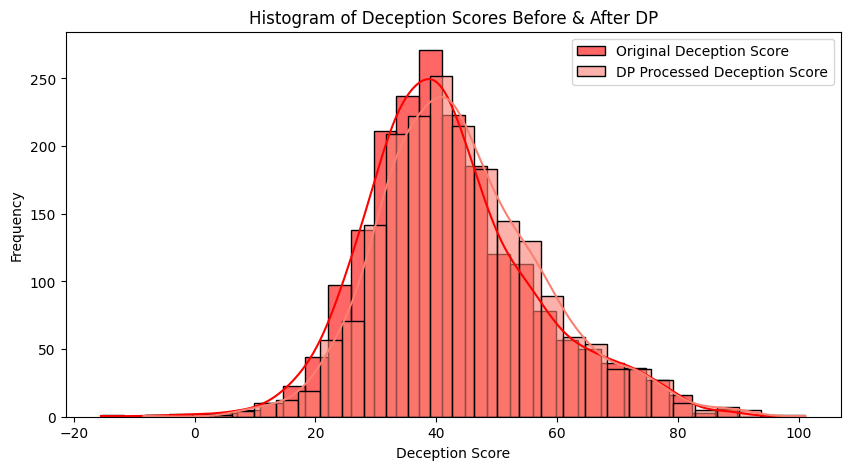

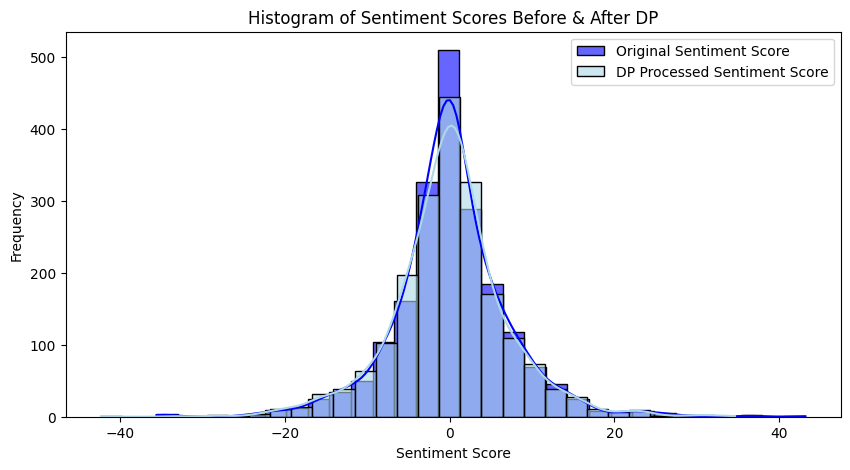

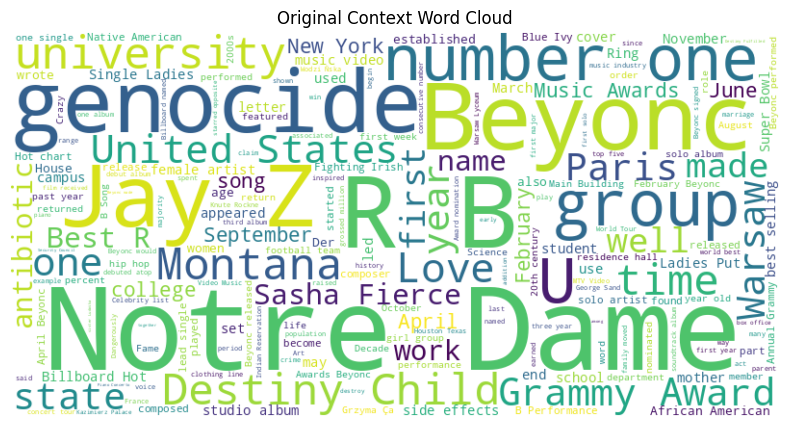

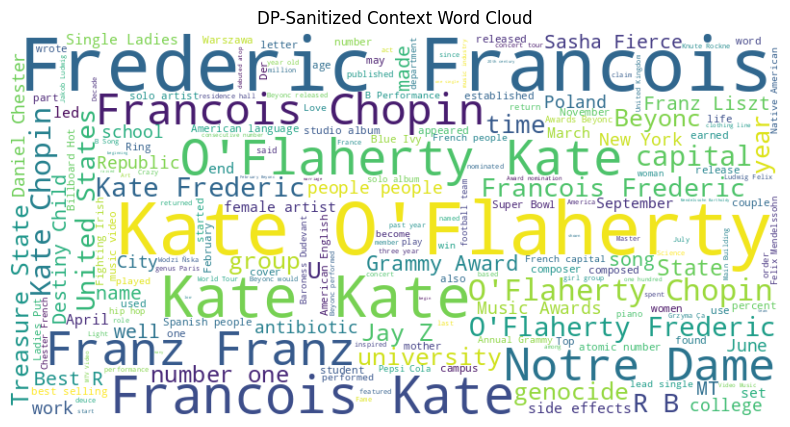

In [3]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from wordcloud import WordCloud
from textblob import TextBlob
from google.colab import files
import hashlib
from numpy.random import laplace
from sentence_transformers import SentenceTransformer, util

# Upload file manually
uploaded = files.upload()

# Get filename from uploaded file
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

# Read Excel file into DataFrame
df_squad = pd.read_excel(filename, engine='openpyxl')

# Display first few rows
df_squad.head()

# Download required NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spaCy NLP model for Named Entity Recognition (CPU-only)
nlp = spacy.load("en_core_web_sm")

# Load stop words
stop_words = set(stopwords.words("english"))

# Load Sentence Transformer for better synonym selection
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

# Initialize Privacy Budget
GLOBAL_EPSILON = 1.0  # Set total privacy budget
privacy_budget_used = 0  # Track cumulative privacy cost

# Function to update privacy budget
def update_privacy_budget(epsilon):
    global privacy_budget_used
    privacy_budget_used += epsilon
    return epsilon

# Function to generate DP-based synonyms dynamically with semantic similarity filtering
def get_semantic_synonym(word, epsilon=0.2):  # Use small epsilon per query
    update_privacy_budget(epsilon)
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ")
            if synonym.lower() != word.lower():
                synonyms.add(synonym)
    synonyms = list(synonyms)

    if not synonyms:
        return word  # Return original word if no synonyms are found

    word_embedding = semantic_model.encode(word, convert_to_tensor=True)
    synonym_embeddings = semantic_model.encode(synonyms, convert_to_tensor=True)
    similarities = util.pytorch_cos_sim(word_embedding, synonym_embeddings)[0].cpu().numpy()

    scores = np.random.laplace(0, 1 / epsilon, len(synonyms))
    probabilities = np.exp(epsilon * (similarities + scores)) / np.sum(np.exp(epsilon * (similarities + scores)))
    return np.random.choice(synonyms, p=probabilities)

# Function to apply DP-based entity substitution using dynamic synonyms with context awareness
def replace_named_entities(text, epsilon=0.2):
    update_privacy_budget(epsilon)
    doc = nlp(text)
    for ent in doc.ents:
        replacement = get_semantic_synonym(ent.text, epsilon)
        text = text.replace(ent.text, replacement)
    return text

# Function to apply DP-based feature hashing
def hash_with_noise(word, epsilon=0.2):
    update_privacy_budget(epsilon)
    hash_val = int(hashlib.md5(word.encode()).hexdigest(), 16) % (10**8)
    noise = np.random.laplace(0, 1 / epsilon)
    return str(hash_val + int(noise * 1000))

# Function to compute deception score with DP noise
def calculate_deception_score(text, epsilon=0.2):
    update_privacy_budget(epsilon)
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    clarity_score = textstat.flesch_reading_ease(text)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    return deception_score + laplace(0, 1 / epsilon)

# Function to compute sentiment score using TextBlob with DP noise
def calculate_sentiment(text, epsilon=0.2):
    update_privacy_budget(epsilon)
    if not text.strip():
        return 0.0  # Neutral sentiment
    sentiment_score = TextBlob(text).sentiment.polarity
    return sentiment_score + laplace(0, 1 / epsilon)

# Apply DP text sanitization
df_squad["sanitized_context"] = df_squad["context"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=0.2))
df_squad["sanitized_question"] = df_squad["question"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=0.2))

# Compute deception scores with DP noise
df_squad["original_deception"] = df_squad["context"].astype(str).apply(lambda x: calculate_deception_score(x, epsilon=0.2))
df_squad["dp_deception"] = df_squad["sanitized_context"].astype(str).apply(lambda x: calculate_deception_score(x, epsilon=0.2))

# Compute sentiment scores with DP noise
df_squad["original_sentiment"] = df_squad["context"].astype(str).apply(lambda x: calculate_sentiment(x, epsilon=0.2))
df_squad["dp_sentiment"] = df_squad["sanitized_context"].astype(str).apply(lambda x: calculate_sentiment(x, epsilon=0.2))

# Save processed dataset
processed_file_path = "dp_sanitized_squad.xlsx"
df_squad.to_excel(processed_file_path, index=False)
print(f"✅ DP-processed dataset saved as: {processed_file_path}")
print(f"🔹 Total Privacy Budget Used: {privacy_budget_used} (out of {GLOBAL_EPSILON})")


# 📊 Improved Visualization: Histogram for Deception Score Comparison
plt.figure(figsize=(10, 5))
sns.histplot(df_squad["original_deception"], color="red", alpha=0.6, bins=30, label="Original Deception Score", kde=True)
sns.histplot(df_squad["dp_deception"], color="salmon", alpha=0.6, bins=30, label="DP Processed Deception Score", kde=True)
plt.xlabel("Deception Score")
plt.ylabel("Frequency")
plt.title("Histogram of Deception Scores Before & After DP")
plt.legend()
plt.show()

# 📊 Improved Visualization: Histogram for Sentiment Score Comparison
plt.figure(figsize=(10, 5))
sns.histplot(df_squad["original_sentiment"], color="blue", alpha=0.6, bins=30, label="Original Sentiment Score", kde=True)
sns.histplot(df_squad["dp_sentiment"], color="lightblue", alpha=0.6, bins=30, label="DP Processed Sentiment Score", kde=True)
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Histogram of Sentiment Scores Before & After DP")
plt.legend()
plt.show()

# 📊 Generate Word Clouds
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

original_text = " ".join(df_squad["context"].dropna())
dp_text = " ".join(df_squad["sanitized_context"].dropna())

generate_wordcloud(original_text, "Original Context Word Cloud")
generate_wordcloud(dp_text, "DP-Sanitized Context Word Cloud")


In [2]:
! pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 57.0 MB/s eta 0:00:00


Saving Squad.xlsx to Squad.xlsx
✅ Uploaded file: Squad.xlsx


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


✅ DP-processed dataset saved as: dp_sanitized_squad.xlsx


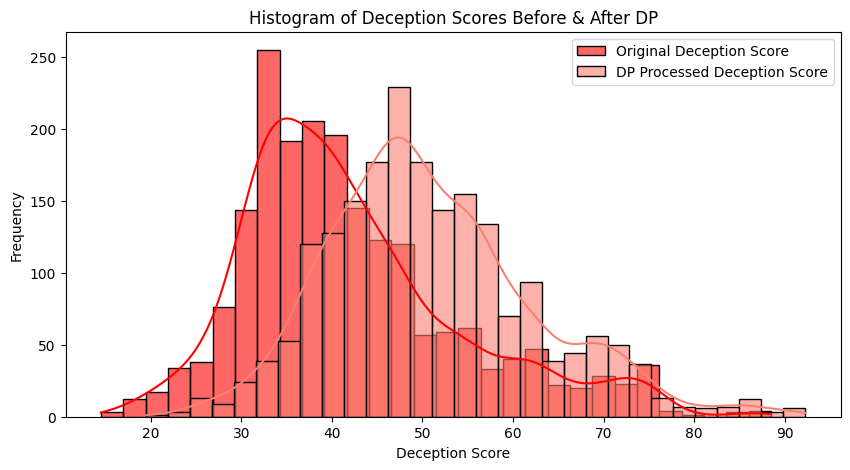

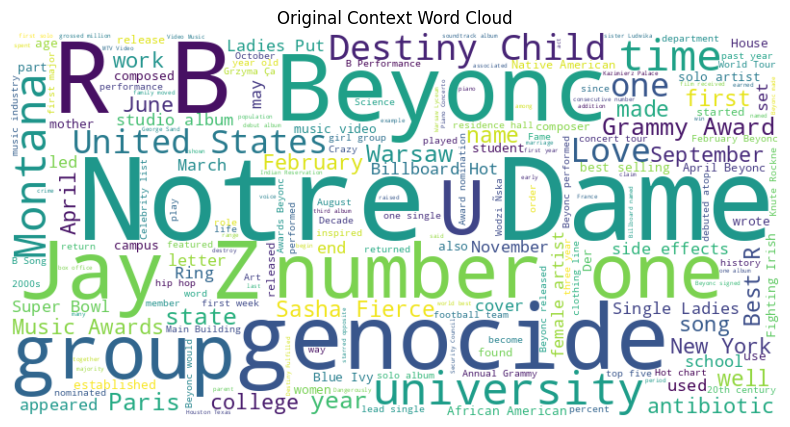

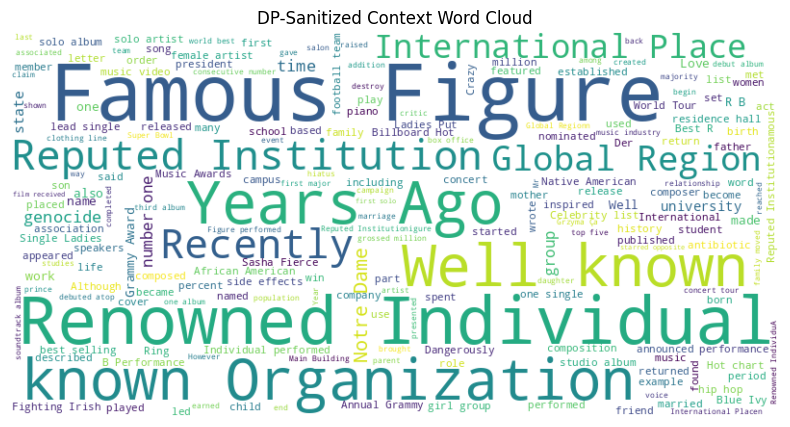

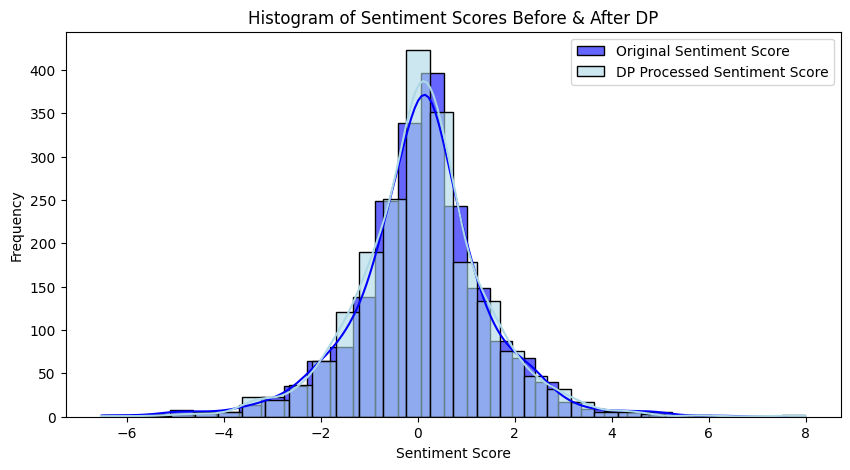

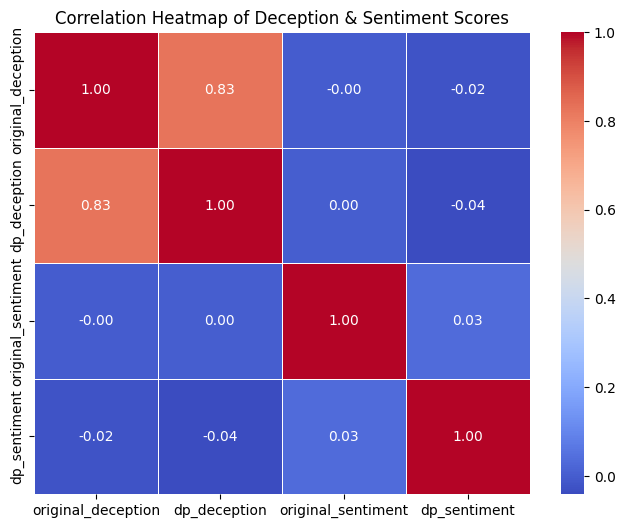

,original_deception,dp_deception,original_sentiment,dp_sentiment
0,29.199192,29.705164,0.024235,0.554135
1,25.934937,33.681845,0.669716,0.217111
2,26.896562,34.625832,-0.755067,1.044584
3,26.149775,37.996992,-0.024851,0.938130
4,28.226787,29.387386,-0.622017,-0.700566
5,45.435537,55.288425,0.339629,1.824568
6,48.684789,56.336437,0.260073,0.534445
7,49.316381,55.735690,-0.056254,1.362118
8,48.737530,56.611529,-1.338044,0.192936
9,46.818063,56.182179,2.007925,-0.051762


In [3]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from wordcloud import WordCloud
from textblob import TextBlob
from google.colab import files
import hashlib
from numpy.random import laplace

# Upload file manually
uploaded = files.upload()

# Get filename from uploaded file
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

# Read Excel file into DataFrame
df_squad = pd.read_excel(filename, engine='openpyxl')

# Display first few rows
df_squad.head()

# Download required NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spaCy NLP model for Named Entity Recognition (CPU-only)
nlp = spacy.load("en_core_web_sm")

# Load stop words
stop_words = set(stopwords.words("english"))

# Function to apply DP-based entity substitution using the Exponential Mechanism
def replace_named_entities(text, epsilon=1.0):
    entity_replacements = {
        "PERSON": ["A Famous Figure", "A Renowned Individual"],
        "ORG": ["A Well-known Organization", "A Reputed Institution"],
        "GPE": ["A Global Region", "An International Place"],
        "DATE": ["Recently", "A Few Years Ago"],
        "TIME": ["Earlier Today", "Some Hours Ago"]
    }

    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in entity_replacements:
            scores = np.random.laplace(0, 1 / epsilon, len(entity_replacements[ent.label_]))
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
            text = text.replace(ent.text, np.random.choice(entity_replacements[ent.label_], p=probabilities))

    return text

# Function to apply DP-based feature hashing
def hash_with_noise(word, epsilon=1.0):
    hash_val = int(hashlib.md5(word.encode()).hexdigest(), 16) % (10**8)
    noise = np.random.laplace(0, 1 / epsilon)
    return str(hash_val + int(noise * 1000))

# Function to compute deception score with DP noise
def calculate_deception_score(text, epsilon=1.0):
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    clarity_score = textstat.flesch_reading_ease(text)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    # Adding Laplace noise to deception score for DP compliance
    return deception_score + laplace(0, 1 / epsilon)

# Function to compute sentiment score using TextBlob with DP noise
def calculate_sentiment(text, epsilon=1.0):
    if not text.strip():
        return 0.0  # Neutral sentiment
    sentiment_score = TextBlob(text).sentiment.polarity
    # Adding Laplace noise to sentiment score
    return sentiment_score + laplace(0, 1 / epsilon)

# Apply DP text sanitization
df_squad["sanitized_context"] = df_squad["context"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=1.0))
df_squad["sanitized_question"] = df_squad["question"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=1.0))

# Compute deception scores with DP noise
df_squad["original_deception"] = df_squad["context"].astype(str).apply(lambda x: calculate_deception_score(x, epsilon=1.0))
df_squad["dp_deception"] = df_squad["sanitized_context"].astype(str).apply(lambda x: calculate_deception_score(x, epsilon=1.0))

# Compute sentiment scores with DP noise
df_squad["original_sentiment"] = df_squad["context"].astype(str).apply(lambda x: calculate_sentiment(x, epsilon=1.0))
df_squad["dp_sentiment"] = df_squad["sanitized_context"].astype(str).apply(lambda x: calculate_sentiment(x, epsilon=1.0))

# Save processed dataset
processed_file_path = "dp_sanitized_squad.xlsx"
df_squad.to_excel(processed_file_path, index=False)
print(f"✅ DP-processed dataset saved as: {processed_file_path}")

# 📊 Improved Visualization: Histogram for Deception Score Comparison
plt.figure(figsize=(10, 5))
sns.histplot(df_squad["original_deception"], color="red", alpha=0.6, bins=30, label="Original Deception Score", kde=True)
sns.histplot(df_squad["dp_deception"], color="salmon", alpha=0.6, bins=30, label="DP Processed Deception Score", kde=True)
plt.xlabel("Deception Score")
plt.ylabel("Frequency")
plt.title("Histogram of Deception Scores Before & After DP")
plt.legend()
plt.show()

# 📊 Generate Word Clouds
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

original_text = " ".join(df_squad["context"].dropna())
dp_text = " ".join(df_squad["sanitized_context"].dropna())

generate_wordcloud(original_text, "Original Context Word Cloud")
generate_wordcloud(dp_text, "DP-Sanitized Context Word Cloud")

# 📊 Improved Visualization: Histogram for Sentiment Score Comparison
plt.figure(figsize=(10, 5))
sns.histplot(df_squad["original_sentiment"], color="blue", alpha=0.6, bins=30, label="Original Sentiment Score", kde=True)
sns.histplot(df_squad["dp_sentiment"], color="lightblue", alpha=0.6, bins=30, label="DP Processed Sentiment Score", kde=True)
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Histogram of Sentiment Scores Before & After DP")
plt.legend()
plt.show()

# Select numeric columns for visualization
num_cols = ["original_deception", "dp_deception", "original_sentiment", "dp_sentiment"]

# 📊 Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(df_squad[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Deception & Sentiment Scores")
plt.show()

# 📊 Styled Gradient Table for Numerical Values
styled_table = df_squad[num_cols].head(10).style.background_gradient(cmap="coolwarm")
display(styled_table)